Drugs Dataset


Hamzah Fawzy 211000489

This is the link to my dataset i will be using: https://www.kaggle.com/datasets/rouzbeh/introds

1) Part 1

In [1]:
#================================================================================================================#

#                                  Import Dataset

#================================================================================================================#

import pandas as pd
import numpy as np

df = pd.read_csv("/Users/hamoaster/Downloads/train.csv")

df.head(5)

#================================================================================================================#

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
1,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
2,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50


In [2]:
#================================================================================================================#

#                         shakleyat!

#================================================================================================================#

df = df.drop(columns=['Unnamed: 0'])

df.head(3)

#================================================================================================================#

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.5
1,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.5
2,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.0


In [3]:
#================================================================================================================#

#                                      Cleaning if needed

#================================================================================================================#


# 1) Checking for null values
null_values = df.isnull()
null_counts = null_values.sum()
print("Number of null values:\n", null_counts)


# 2) Check for duplicates
duplicates = df[df.duplicated()]
print("\nDuplicated rows:\n", duplicates)


print("_______________________________________________________")
#================================================================================================================#

# 3) Drop Null values from New_Price
df = df.dropna()
null_values_later = df.isnull()
null_counts_later = null_values_later.sum()
print("\nNumber of null values after cleaning:\n", null_counts_later)

# 4) No dupes!

#================================================================================================================#

Number of null values:
 Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  38
New_Price            5032
Price                   0
dtype: int64

Duplicated rows:
 Empty DataFrame
Columns: [Name, Location, Year, Kilometers_Driven, Fuel_Type, Transmission, Owner_Type, Mileage, Engine, Power, Seats, New_Price, Price]
Index: []
_______________________________________________________

Number of null values after cleaning:
 Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
New_Price            0
Price                0
dtype: int64


In [4]:
#================================================================================================================#

#                      Descriptive statistics

#================================================================================================================#

selected_columns = ['Kilometers_Driven', 'Seats', 'Price']

mean_values = df[selected_columns].mean()
print("Mean values:")
print(mean_values)

mode_values = df[selected_columns].mode().iloc[0]  # Mode returns a Series, so use iloc[0] to get the first mode
print("\nMode values:")
print(mode_values)

median_values = df[selected_columns].median()
print("\nMedian values:")
print(median_values)

variance_values = df[selected_columns].var()
print("\nVariance values:")
print(variance_values)

std_dev_values = df[selected_columns].std()
print("\nStandard Deviation values:")
print(std_dev_values)

#================================================================================================================#

Mean values:
Kilometers_Driven    40318.427518
Seats                    5.309582
Price                   13.759054
dtype: float64

Mode values:
Kilometers_Driven    45000.0
Seats                    5.0
Price                    4.5
Name: 0, dtype: float64

Median values:
Kilometers_Driven    34669.50
Seats                    5.00
Price                    8.25
dtype: float64

Variance values:
Kilometers_Driven    8.324346e+08
Seats                6.371282e-01
Price                2.221398e+02
dtype: float64

Standard Deviation values:
Kilometers_Driven    28851.943168
Seats                    0.798203
Price                   14.904356
dtype: float64


In [5]:
#================================================================================================================#

df.dtypes

#================================================================================================================#

Name                  object
Location              object
Year                   int64
Kilometers_Driven      int64
Fuel_Type             object
Transmission          object
Owner_Type            object
Mileage               object
Engine                object
Power                 object
Seats                float64
New_Price             object
Price                float64
dtype: object

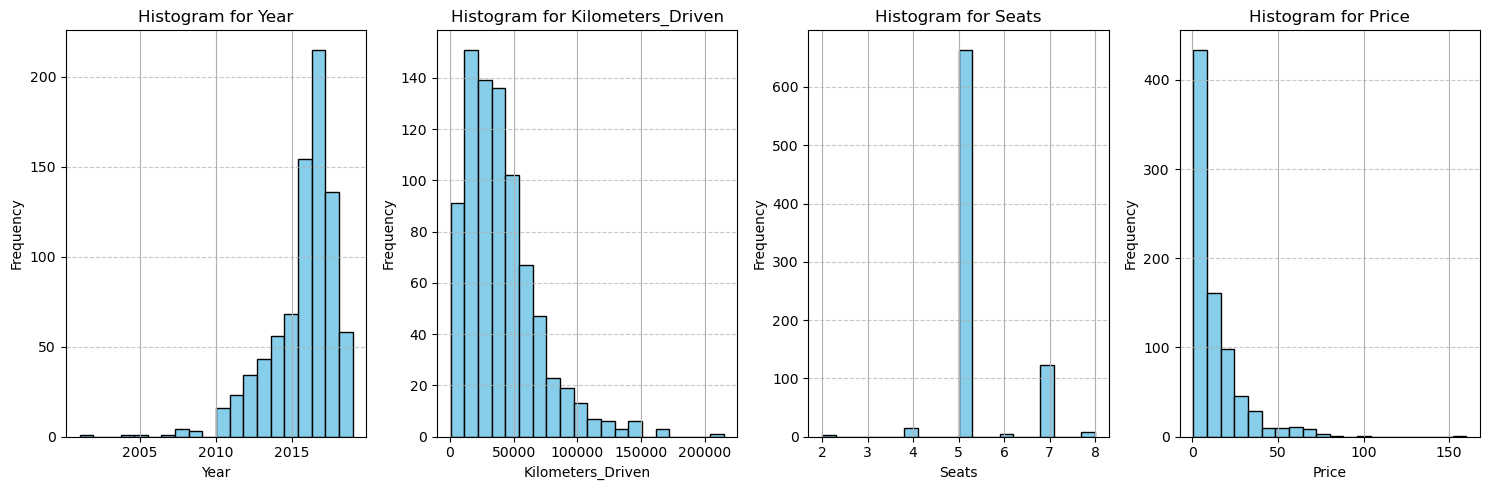

In [6]:
#================================================================================================================#

#                                     Histogram for evey numerical column

#================================================================================================================#

import matplotlib.pyplot as plt

numeric_columns = ['Year', 'Kilometers_Driven', 'Seats', 'Price']

fig, axes = plt.subplots(nrows=1, ncols=len(numeric_columns), figsize=(15, 5))

for i, col in enumerate(numeric_columns):
    df[col].hist(ax=axes[i], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histogram for {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#================================================================================================================#

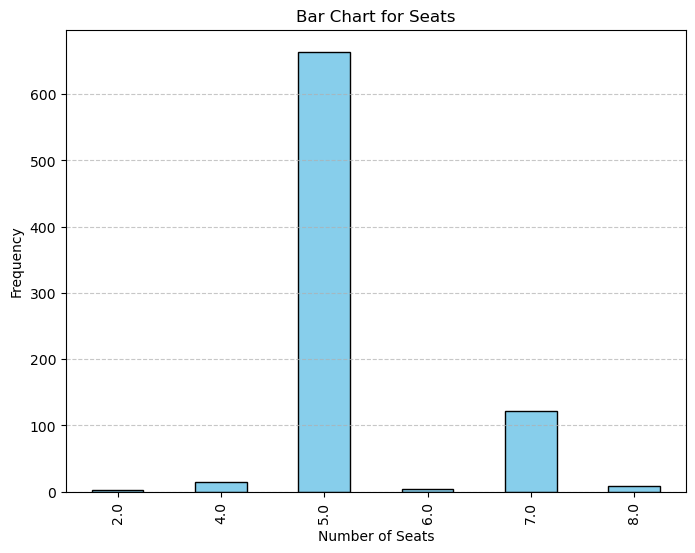

In [7]:
#================================================================================================================#

#                                 Bar chart for seats

#================================================================================================================#

import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))
df['Seats'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Bar Chart for Seats')
plt.xlabel('Number of Seats')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#================================================================================================================#

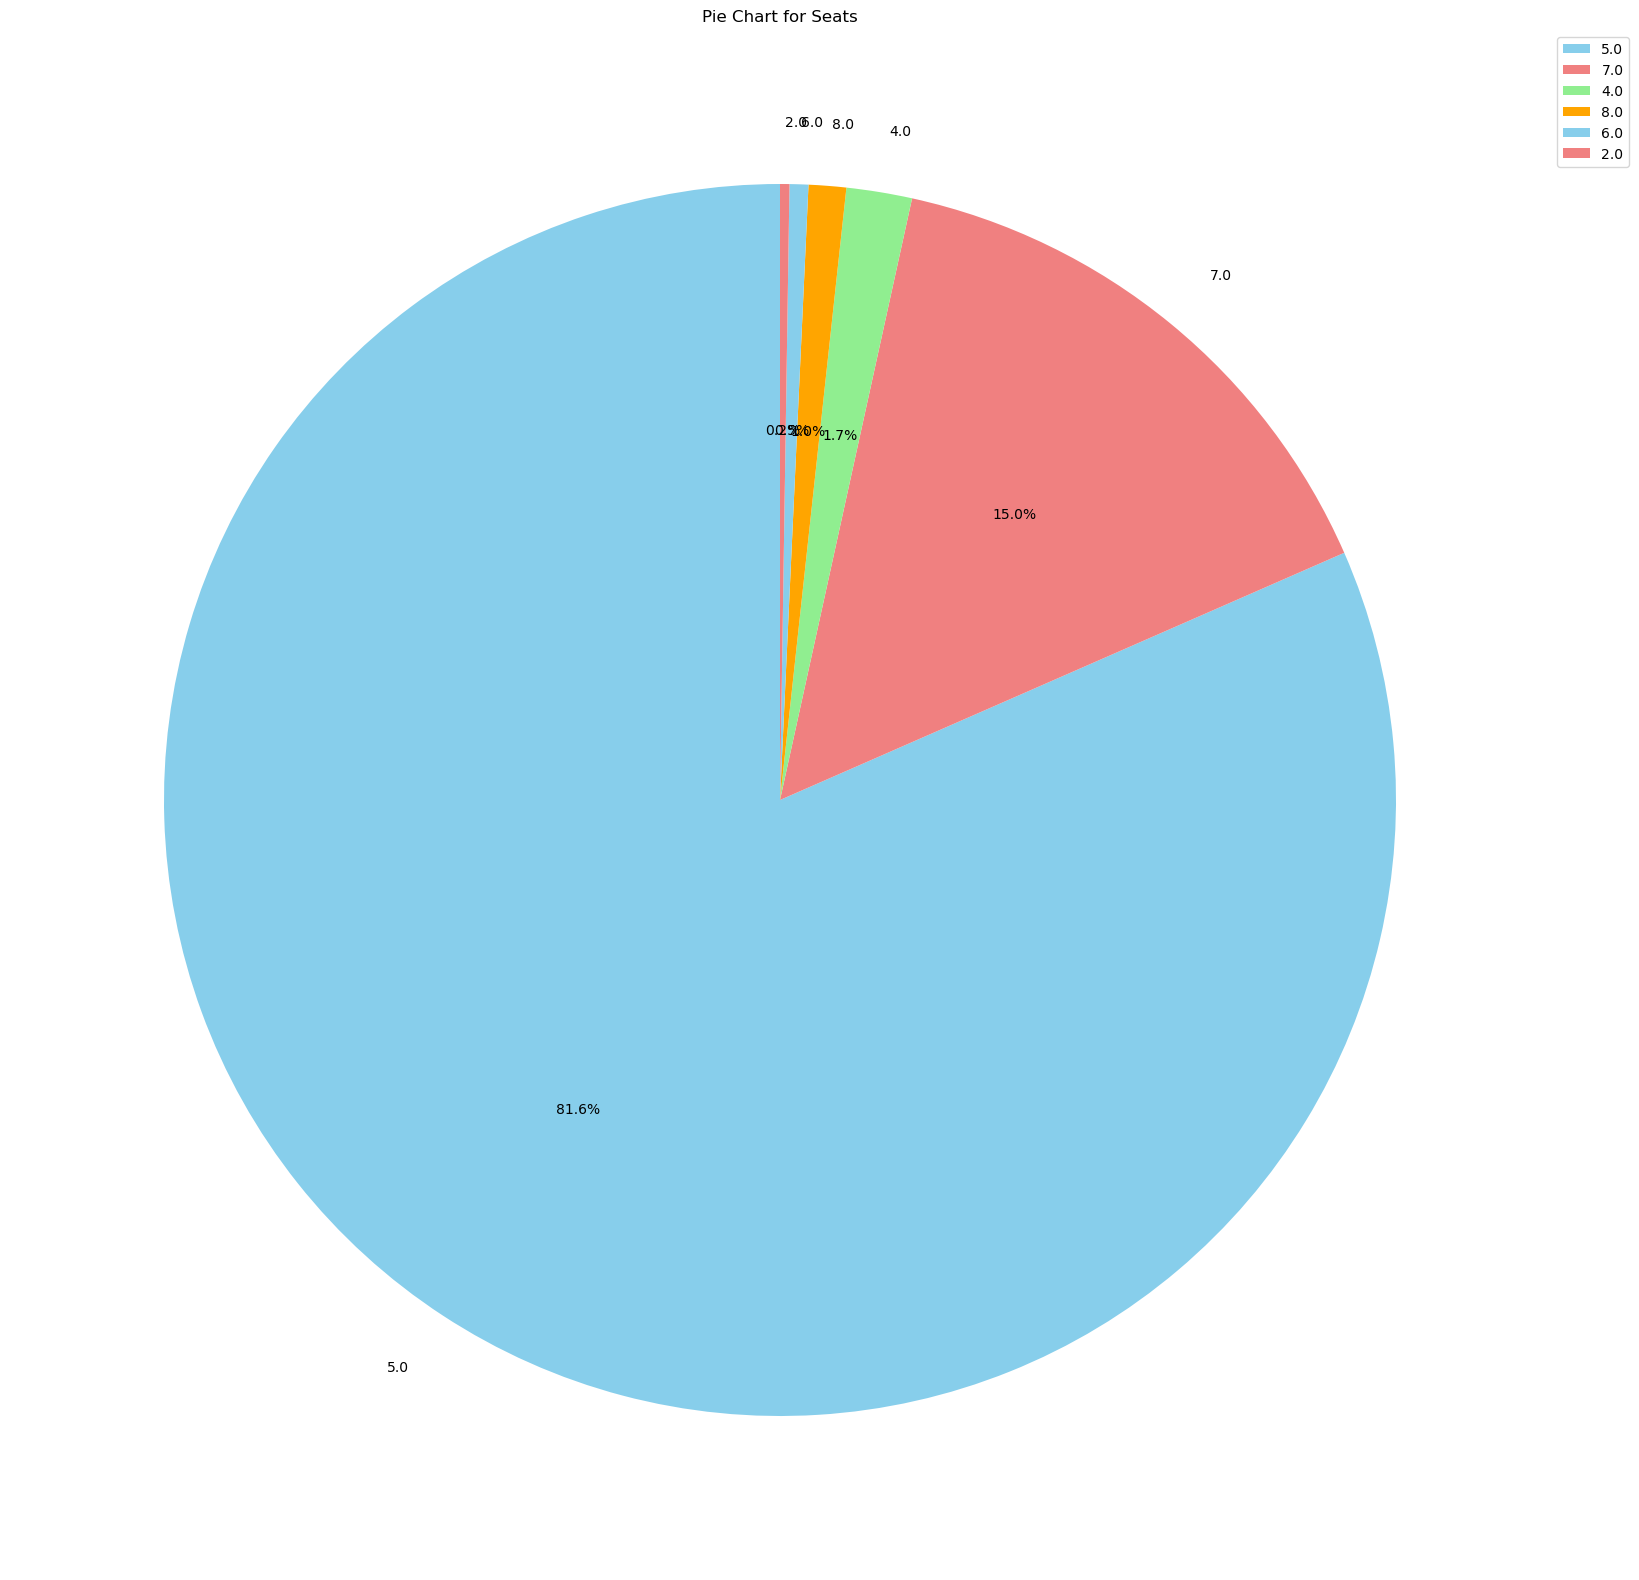

In [8]:
#================================================================================================================#

#                                 Pie chart for seats. Im sorry heya mo3awka shwaya
#                                          bas sha8ala wallahi

#================================================================================================================#

plt.figure(figsize=(20, 20))
pie_chart = df['Seats'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral', 'lightgreen', 'orange'])

plt.legend(bbox_to_anchor=(1, 1), loc='upper left')

plt.title('Pie Chart for Seats')
plt.ylabel('')
plt.show()

#================================================================================================================#

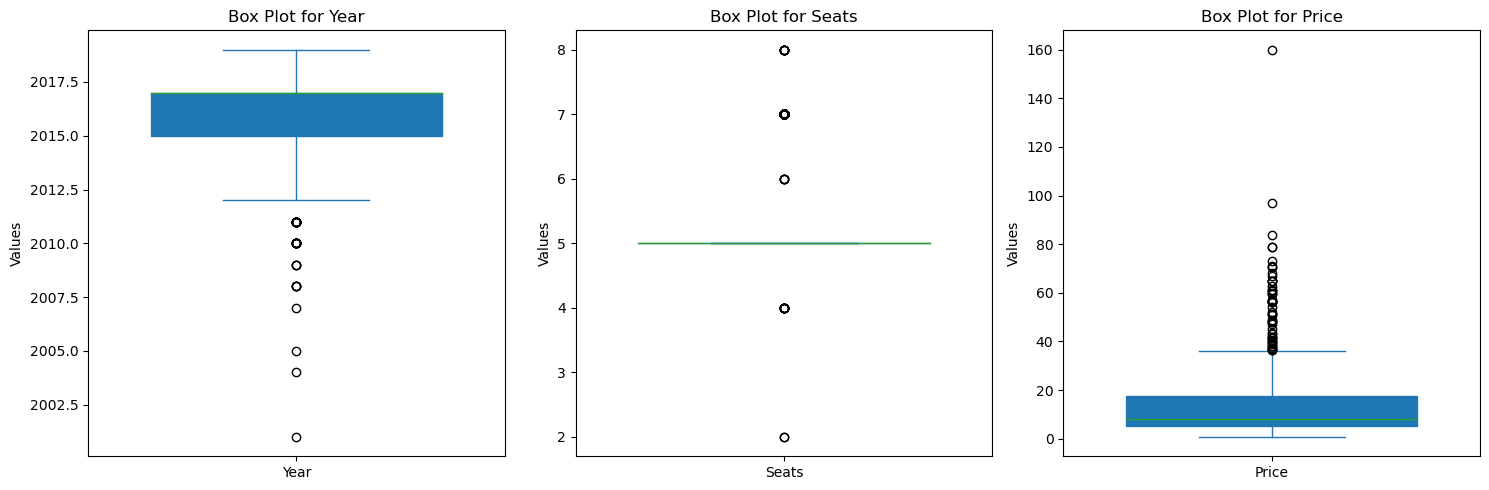

In [9]:
#================================================================================================================#

#                                          Box Plot

#================================================================================================================#
selected_columns = ['Year', 'Seats', 'Price']

fig, axes = plt.subplots(1, len(selected_columns), figsize=(15, 5))

for i, col in enumerate(selected_columns):
    df[col].plot(kind='box', ax=axes[i], sym='o', patch_artist=True, widths=0.7)
    axes[i].set_title(f'Box Plot for {col}')
    axes[i].set_ylabel('Values')

plt.tight_layout()
plt.show()


#================================================================================================================#

/var/folders/y8/89kfn0qx7v3f202xphbd023r0000gn/T/ipykernel_1439/630035545.py:10: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=.5)


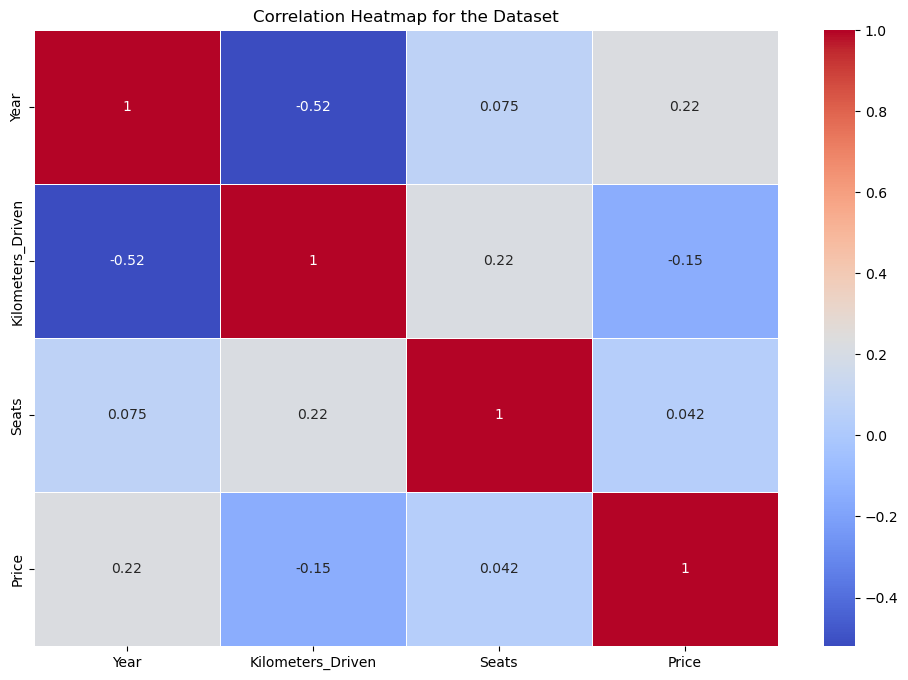

In [10]:
#================================================================================================================#

#                                  Heat map!

#================================================================================================================#

import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Heatmap for the Dataset')
plt.show()

#================================================================================================================#

In [11]:
#================================================================================================================#

#                               Pearson & Spearman

#================================================================================================================#

from scipy.stats import pearsonr, spearmanr

column1 = 'Kilometers_Driven'
column2 = 'Price'

pearson_corr, _ = pearsonr(df[column1], df[column2])
print(f"Pearson Correlation Coefficient between {column1} and {column2}: {pearson_corr:.4f}")

spearman_corr, _ = spearmanr(df[column1], df[column2])
print(f"Spearman Correlation Coefficient between {column1} and {column2}: {spearman_corr:.4f}")

#================================================================================================================#

Pearson Correlation Coefficient between Kilometers_Driven and Price: -0.1511
Spearman Correlation Coefficient between Kilometers_Driven and Price: -0.1640


2) Part 2

In [22]:
#================================================================================================================#

#                  Calculating the 95% confidence interval of the population mean of any column

#================================================================================================================#

from scipy.stats import t
from statistics import stdev

column1 = 'Price'

# sample the datav
sample_data = df[column1].sample(n=100, random_state=42)

# mean and standard deviation of the sample
sample_mean = np.mean(sample_data)
sample_std = stdev(sample_data)

confidence_level = 0.95
alpha = 1 - confidence_level
degrees_of_freedom = len(sample_data) - 1
t_critical = t.ppf(1 - alpha / 2, df=degrees_of_freedom)
margin_of_error = t_critical * (sample_std / np.sqrt(len(sample_data)))

confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)

print(f"95% Confidence Interval for the Population Mean of {column1}: {confidence_interval}")

#================================================================================================================#

95% Confidence Interval for the Population Mean of Price: (10.325723766523558, 14.74107623347644)


In [29]:
#================================================================================================================#

#                  hypothesis testing on the mean and variance value for any column

#================================================================================================================#

from scipy.stats import ttest_1samp, chi2

column2 = 'Price'

sample_data = df[column2].sample(n=100, random_state=42)

# Hypothesis testing for the mean
null_hypothesis_mean = 0  # If our mean was to be 0
t_statistic_mean, p_value_mean = ttest_1samp(sample_data, null_hypothesis_mean)
print(f"Hypothesis Testing for Mean of {column2}: t-statistic = {t_statistic_mean}, p-value = {p_value_mean}")

# Hypothesis testing for the variance using Chi-Square
null_hypothesis_variance = 1  # If our variance was to be 1
chi2_statistic = ((len(sample_data) - 1) * np.var(sample_data)) / null_hypothesis_variance
p_value_variance = 1 - chi2.cdf(chi2_statistic, df=len(sample_data) - 1)
print(f"Hypothesis Testing for Variance of {column2}: Chi-Squared statistic = {chi2_statistic}, p-value = {p_value_variance}")

#================================================================================================================#

Hypothesis Testing for Mean of Price: t-statistic = 11.264778939472286, p-value = 1.9521100090349474e-19
Hypothesis Testing for Variance of Price: Chi^2 statistic = 12132.850399560004, p-value = 0.0


In [39]:
#================================================================================================================#

#                  hypothesis testing on the population mean for 2 columns

#================================================================================================================#

column1 = 'Price'
column2 = 'Kilometers_Driven'

# Sample the data
sample_data_column1 = df[column1].sample(n=100, random_state=42)
sample_data_column2 = df[column2].sample(n=100, random_state=43)

# Hypothesis testing for the population mean
null_hypothesis_mean_diff = 0  
t_statistic_2columns, p_value_2columns = ttest_ind(sample_data_column1, sample_data_column2)
print(f"Hypothesis Testing for Population Mean between {column1} and {column2}: t-statistic = {t_statistic_2columns}, p-value = {p_value_2columns}")

#================================================================================================================#

Hypothesis Testing for Population Mean between Price and Kilometers_Driven: t-statistic = -14.08296573941648, p-value = 1.1573799995950507e-31


In [38]:
#================================================================================================================#

#                  Hypothesis Testing on the Population Mean for More Than 2 Columns

#================================================================================================================#

column1 = 'Price'
column2 = 'Kilometers_Driven'
column3 = 'Seats'

# Sample the data
sample_data_column1 = df[column1].sample(n=100, random_state=42)
sample_data_column2 = df[column2].sample(n=100, random_state=43)
sample_data_column3 = df[column3].sample(n=100, random_state=44)

# Conduct t-tests for each pair of columns
t_statistic_1_2, p_value_1_2 = ttest_ind(sample_data_column1, sample_data_column2)
t_statistic_1_3, p_value_1_3 = ttest_ind(sample_data_column1, sample_data_column3)
t_statistic_2_3, p_value_2_3 = ttest_ind(sample_data_column2, sample_data_column3)

print("\n Hypothesis Testing for Population Mean between {column1} and {column2}: t-statistic = {t_statistic_1_2}, p-value = {p_value_1_2}")
print("\n Hypothesis Testing for Population Mean between {column1} and {column3}: t-statistic = {t_statistic_1_3}, p-value = {p_value_1_3}")
print("\n Hypothesis Testing for Population Mean between {column2} and {column3}: t-statistic = {t_statistic_2_3}, p-value = {p_value_2_3}")

#================================================================================================================#


 Hypothesis Testing for Population Mean between {column1} and {column2}: t-statistic = {t_statistic_1_2}, p-value = {p_value_1_2}

 Hypothesis Testing for Population Mean between {column1} and {column3}: t-statistic = {t_statistic_1_3}, p-value = {p_value_1_3}

 Hypothesis Testing for Population Mean between {column2} and {column3}: t-statistic = {t_statistic_2_3}, p-value = {p_value_2_3}


In [40]:
#================================================================================================================#

#                  Hypothesis Testing Confidence Interval = 95% & Mean & Variance

#================================================================================================================#
column = 'Price'

sample_data = df[column].sample(n=20, random_state=42)

confidence_level = 0.95
degrees_of_freedom = len(sample_data) - 1

mean_sample = np.mean(sample_data)
standard_error = np.std(sample_data, ddof=1) / np.sqrt(len(sample_data))
margin_of_error = t.ppf((1 + confidence_level) / 2, degrees_of_freedom) * standard_error

confidence_interval = (mean_sample - margin_of_error, mean_sample + margin_of_error)
print("\n 95% Confidence Interval for the Population Mean of {column}: {confidence_interval}")

null_hypothesis_mean = 0  
t_statistic_mean, p_value_mean = ttest_1samp(sample_data, null_hypothesis_mean)
print("\n Hypothesis Testing for Mean of {column}: t-statistic = {t_statistic_mean}, p-value = {p_value_mean}")

null_hypothesis_variance = 1  
chi2_statistic_variance = (len(sample_data) - 1) * np.var(sample_data) / null_hypothesis_variance
p_value_variance = 1 - chi2.cdf(chi2_statistic_variance, df=len(sample_data) - 1)
print("\n Hypothesis Testing for Variance of {column}: Chi-Square statistic = {chi2_statistic_variance}, p-value = {p_value_variance}")



 95% Confidence Interval for the Population Mean of {column}: {confidence_interval}

 Hypothesis Testing for Mean of {column}: t-statistic = {t_statistic_mean}, p-value = {p_value_mean}

 Hypothesis Testing for Variance of {column}: Chi-Square statistic = {chi2_statistic_variance}, p-value = {p_value_variance}
